In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

# Import your architecture components
from DCGAN.vectorized_unet import VectorizedUNet
from DCGAN.unet import UNet
from DCGAN.loss_functions import EntropyLoss, TotalVariationLoss

# ── 1. Dummy Dataset ────────────────────────────────────────────────────────
class DummyShapeDataset(Dataset):
    def __init__(self, num_samples=1000, size=256, max_shapes_per_image=3):
        self.num_samples = num_samples
        self.size = size
        self.max_shapes = max_shapes_per_image
        # Pyramids required by VectorizedUNet
        self.resolutions = [4, 8, 16, 32, 64, 128, 256]
        
    def __len__(self):
        return self.num_samples
        
    def __getitem__(self, idx):
        # 1. White background [3, H, W] -> R=1, G=1, B=1
        img = torch.ones(3, self.size, self.size)
        
        # 2. Add random number of Yellow squares -> R=1, G=1, B=0
        num_squares = torch.randint(1, self.max_shapes + 1, (1,)).item()
        for _ in range(num_squares):
            s = torch.randint(20, 60, (1,)).item() # Size
            y = torch.randint(0, self.size - s, (1,)).item()
            x = torch.randint(0, self.size - s, (1,)).item()
            img[0, y:y+s, x:x+s] = 1.0
            img[1, y:y+s, x:x+s] = 1.0
            img[2, y:y+s, x:x+s] = 0.0
            
        # 3. Add random number of Blue circles -> R=0, G=0, B=1
        num_circles = torch.randint(1, self.max_shapes + 1, (1,)).item()
        for _ in range(num_circles):
            r = torch.randint(10, 30, (1,)).item() # Radius
            cy = torch.randint(r, self.size - r, (1,)).item()
            cx = torch.randint(r, self.size - r, (1,)).item()
            
            y_grid, x_grid = torch.meshgrid(
                torch.arange(self.size), torch.arange(self.size), indexing='ij'
            )
            mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= r**2
            img[0, mask] = 0.0
            img[1, mask] = 0.0
            img[2, mask] = 1.0
            
        # 4. Scale to [-1, 1] for Tanh
        img = img * 2.0 - 1.0
        
        # 5. Create multi-resolution pyramid
        img_pyramid = []
        for res in self.resolutions:
            if res == self.size:
                img_pyramid.append(img)
            else:
                # Downsample for smaller resolutions
                down = F.adaptive_avg_pool2d(img.unsqueeze(0), (res, res)).squeeze(0)
                img_pyramid.append(down)
                
        return img_pyramid, 0 # Return 0 for dummy target

# ── 2. Training Setup ───────────────────────────────────────────────────────


In [2]:
import matplotlib.pyplot as plt

def visualize_results(orig_img, recon_img, masks, epoch, batch_idx):
    """
    orig_img: [C, H, W] tensor
    recon_img: [C, H, W] tensor
    masks: [K, H, W] tensor (probabilities from softmax)
    """
    # Detach, move to CPU, and format for matplotlib
    # Assuming images are normalized [-1, 1], adjust to [0, 1]
    orig = (orig_img.detach().cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    recon = (recon_img.detach().cpu() * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()
    m = masks.detach().cpu().numpy() # [K, H, W]
    
    K = m.shape[0] # Number of masks
    
    # Setup dynamic subplots: 1 for Orig, 1 for Recon, K for Masks
    fig, axes = plt.subplots(1, 2 + K, figsize=(4 + 3 * K, 4))
    
    # Plot Original
    axes[0].imshow(orig)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    # Plot Reconstruction
    axes[1].imshow(recon)
    axes[1].set_title("Reconstruction")
    axes[1].axis('off')
    
    # Plot Each Mask
    for i in range(K):
        ax = axes[2 + i]
        im = ax.imshow(m[i], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f"Mask {i}")
        ax.axis('off')
        
    plt.suptitle(f"Epoch {epoch} | Batch {batch_idx}")
    plt.tight_layout()
    plt.show()
    # plt.savefig(f"vis_ep{epoch}_b{batch_idx}.png") # Use this if running on a remote server without GUI
    # plt.close()

In [3]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Hyperparameters from your notebook
n_components = 3  # Background, Squares, Circles
encoder_channels = [512, 256, 128, 64, 32, 32, 16]
decoder_channels = [64, 32, 32, 16, 16, 16, 16]

# NOTE: Set the first DOF to 512 to avoid the assertion crash with z_dim=512!
degrees_of_freedom = [1, 1, 1, 1, 1, 1, 1]
vectorizer_output_channels = [1, 1, 1, 1, 1, 1]
grid_sizes = [1, 2, 4, 4, 8, 8, 16] 
z_dim  =1
seg_gen_cut_connections = 4
batch_size = 16
epochs = 10

# Datasets
train_ds = DummyShapeDataset(num_samples=1000)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Models
rec_model = VectorizedUNet(
    encoder_channels=encoder_channels,
    decoder_channels=decoder_channels,
    number_of_components=n_components,
    vectorizer_output_channels=vectorizer_output_channels,
    degrees_of_freedom=degrees_of_freedom,
    grid_sizes=grid_sizes,
    z_dim=z_dim
).to(device)

seg_model = UNet(
    channels=encoder_channels,
    out_channels=n_components,
    cut_connections=seg_gen_cut_connections
).to(device)

# Optimizers
rec_optimizer = optim.Adam(rec_model.parameters(), lr=2e-4)
seg_optimizer = optim.Adam(seg_model.parameters(), lr=2e-4)

# Loss Functions
recon_loss_fn = nn.L1Loss()
entropy_loss_fn = EntropyLoss(weight=0.0001)
tv_loss_fn = TotalVariationLoss(weight=0.001)


Using device: cuda


Epoch 0/10:   0%|          | 0/63 [00:01<?, ?it/s, entropy_loss=0.000109, recon_loss=6.8, tv_loss=3.54e-8]

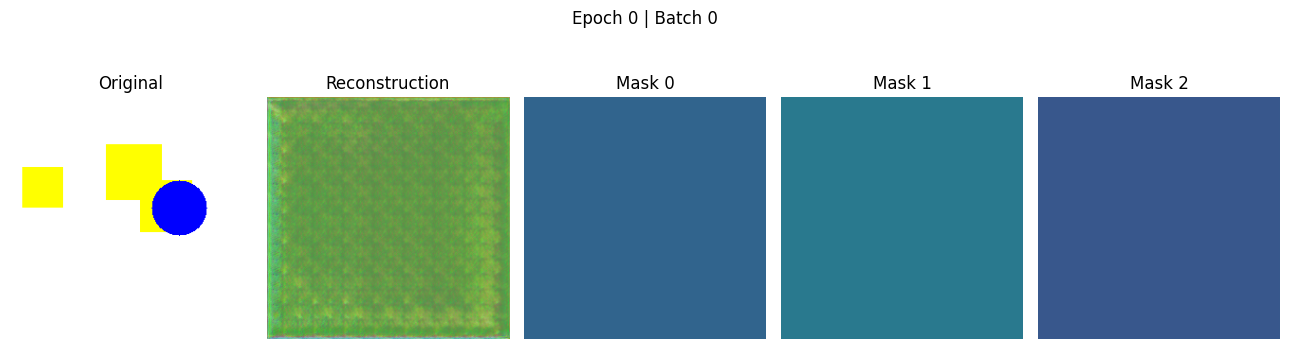

Epoch 0/10:  32%|███▏      | 20/63 [00:07<00:12,  3.31it/s, entropy_loss=0.000109, recon_loss=2.31, tv_loss=3.31e-8]

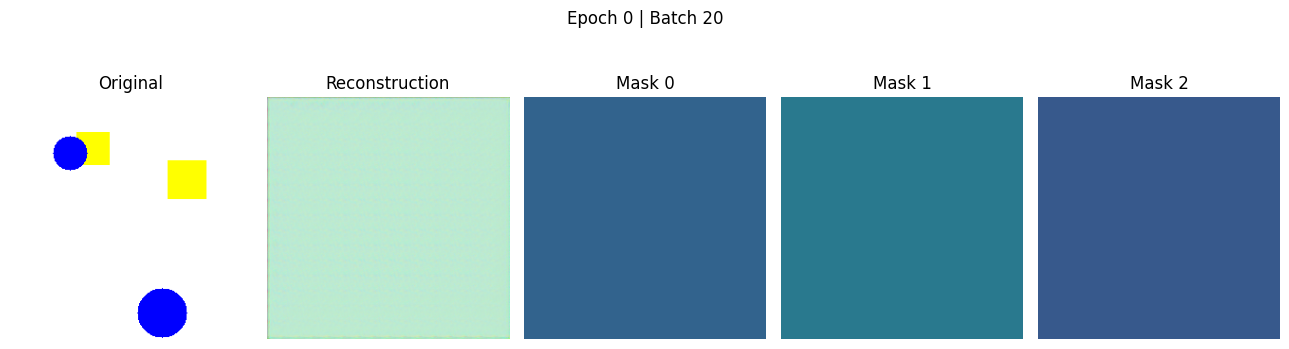

Epoch 0/10:  63%|██████▎   | 40/63 [00:13<00:06,  3.41it/s, entropy_loss=0.000109, recon_loss=1.86, tv_loss=4.43e-8]

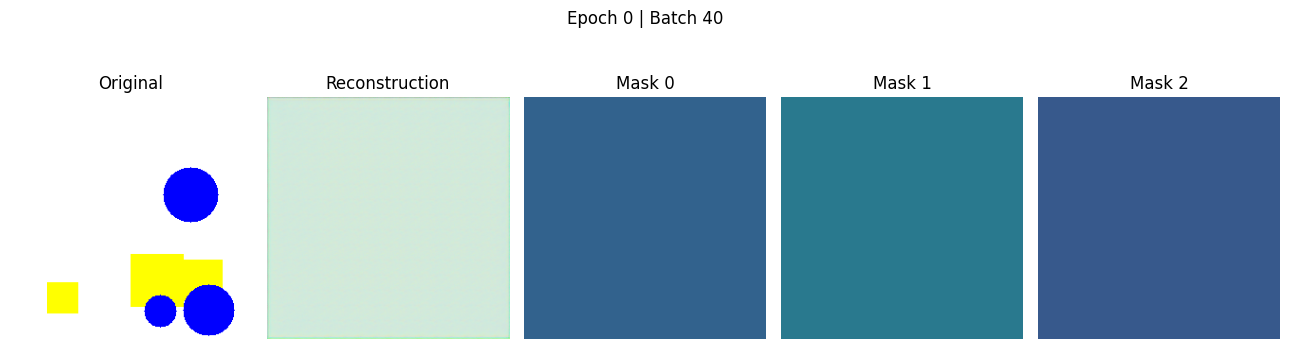

Epoch 0/10:  95%|█████████▌| 60/63 [00:20<00:00,  3.33it/s, entropy_loss=0.000109, recon_loss=1.62, tv_loss=5.17e-8]

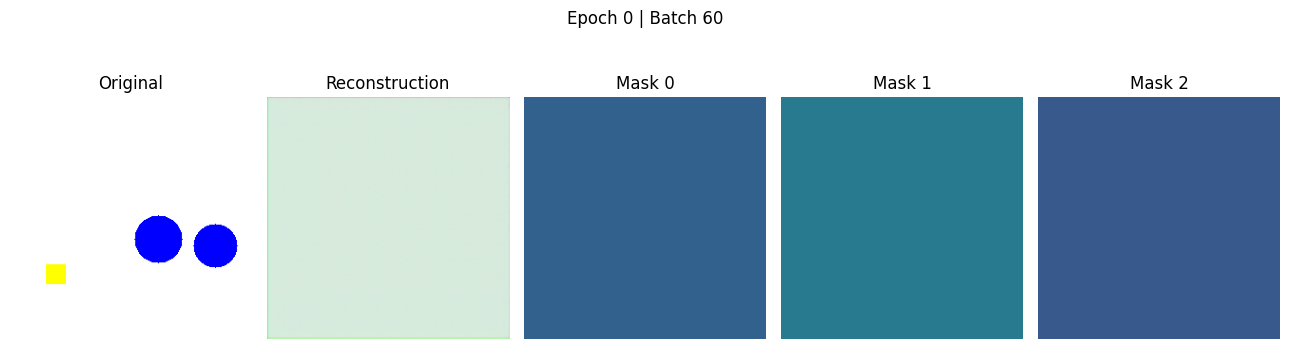

Epoch 0/10: 100%|██████████| 63/63 [00:20<00:00,  3.01it/s, entropy_loss=0.000108, recon_loss=1.64, tv_loss=5.3e-8] 


Epoch 0 complete. Recon Loss: 1.6436


Epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000108, recon_loss=1.66, tv_loss=5.38e-8]

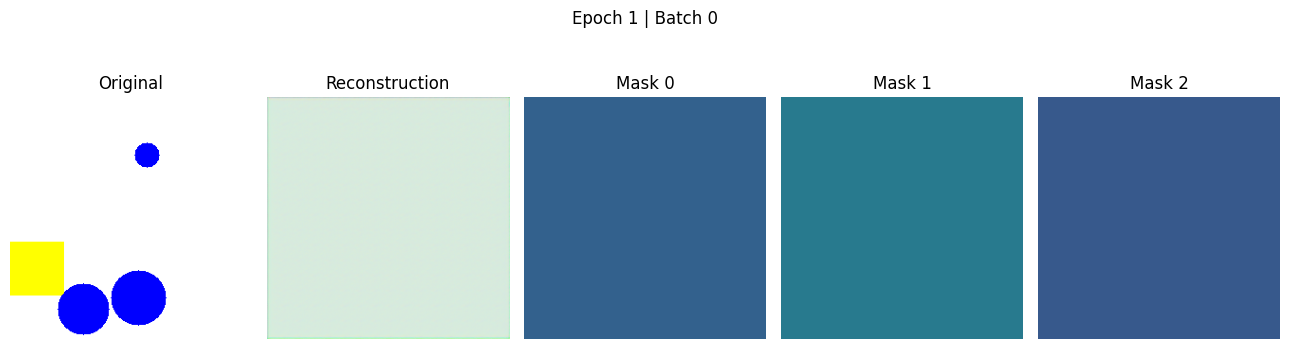

Epoch 1/10:  32%|███▏      | 20/63 [00:06<00:13,  3.31it/s, entropy_loss=0.000108, recon_loss=1.51, tv_loss=4.18e-7]

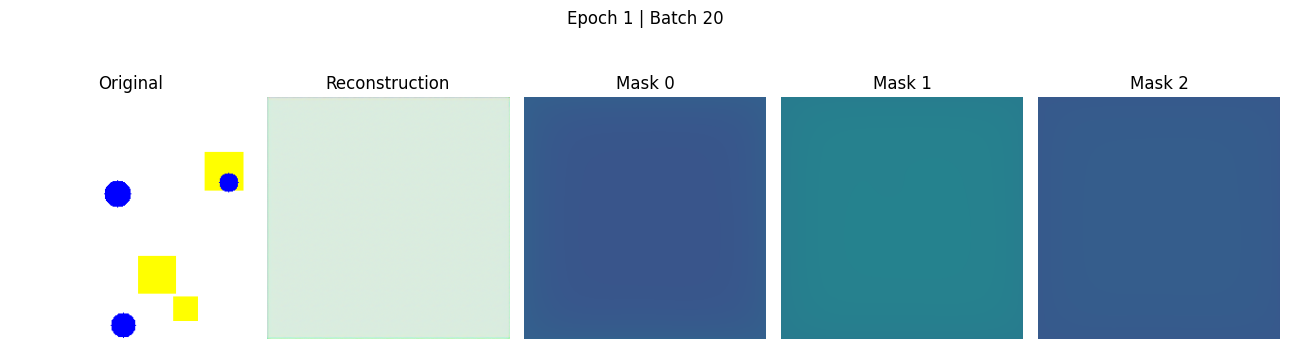

Epoch 1/10:  63%|██████▎   | 40/63 [00:12<00:06,  3.41it/s, entropy_loss=0.000105, recon_loss=1.53, tv_loss=2.01e-6]

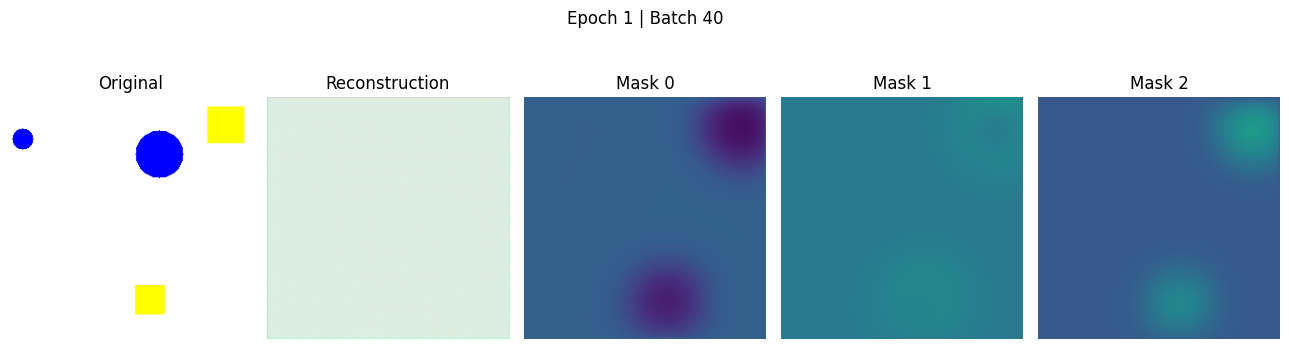

Epoch 1/10:  95%|█████████▌| 60/63 [00:19<00:00,  3.42it/s, entropy_loss=0.000104, recon_loss=1.37, tv_loss=2.41e-6]

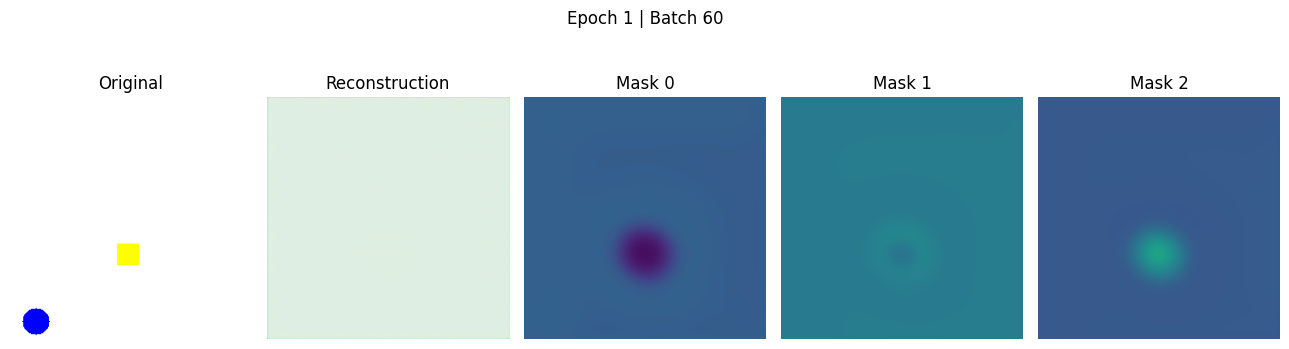

Epoch 1/10: 100%|██████████| 63/63 [00:19<00:00,  3.18it/s, entropy_loss=0.000107, recon_loss=1.41, tv_loss=1.39e-6]


Epoch 1 complete. Recon Loss: 1.4134


Epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000106, recon_loss=1.37, tv_loss=2.04e-6]

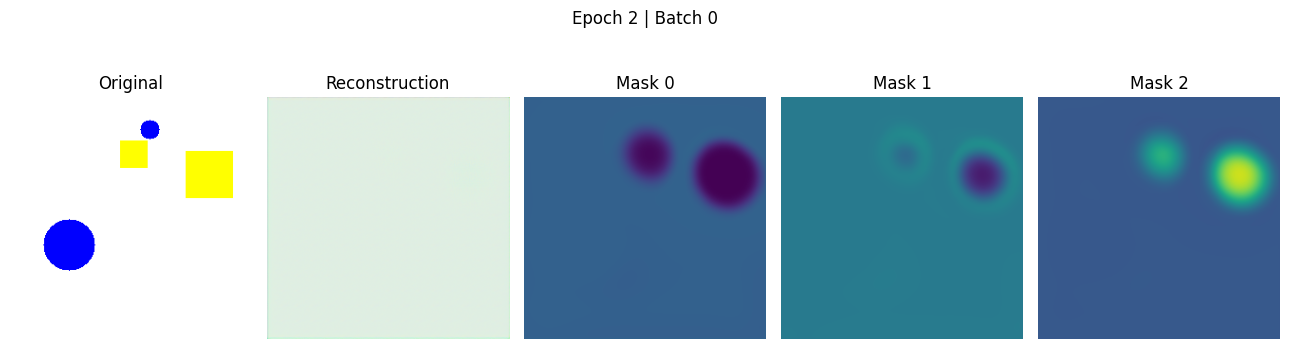

Epoch 2/10:  32%|███▏      | 20/63 [00:06<00:12,  3.36it/s, entropy_loss=9.96e-5, recon_loss=1.28, tv_loss=4.43e-6] 

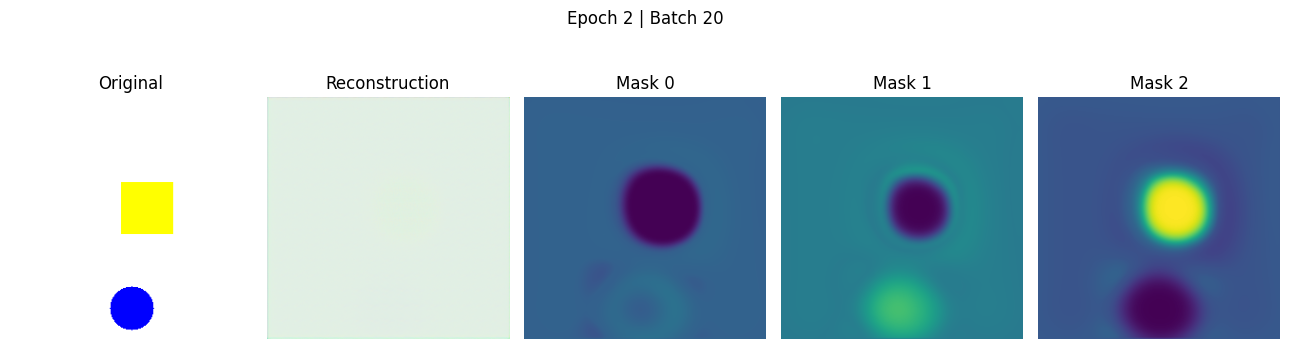

Epoch 2/10:  63%|██████▎   | 40/63 [00:12<00:06,  3.38it/s, entropy_loss=9.74e-5, recon_loss=1.35, tv_loss=5.26e-6]

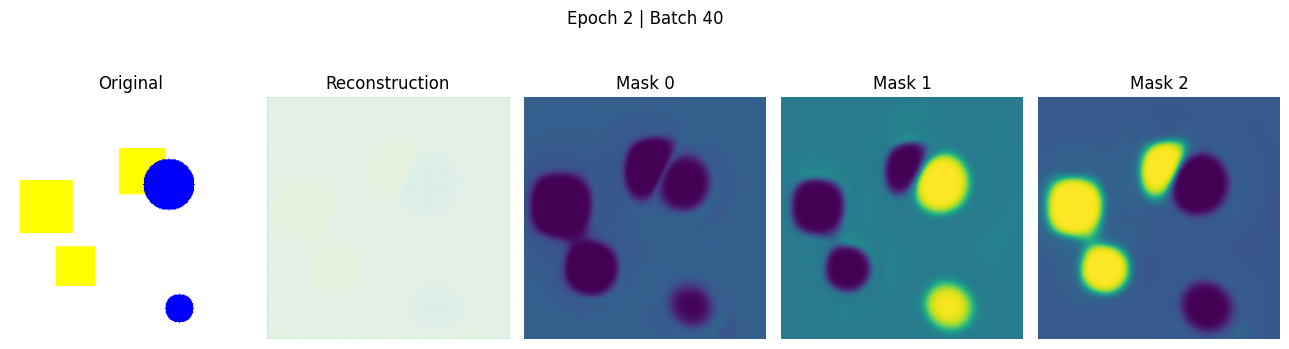

Epoch 2/10:  95%|█████████▌| 60/63 [00:18<00:00,  3.37it/s, entropy_loss=9.78e-5, recon_loss=1.21, tv_loss=5.64e-6]

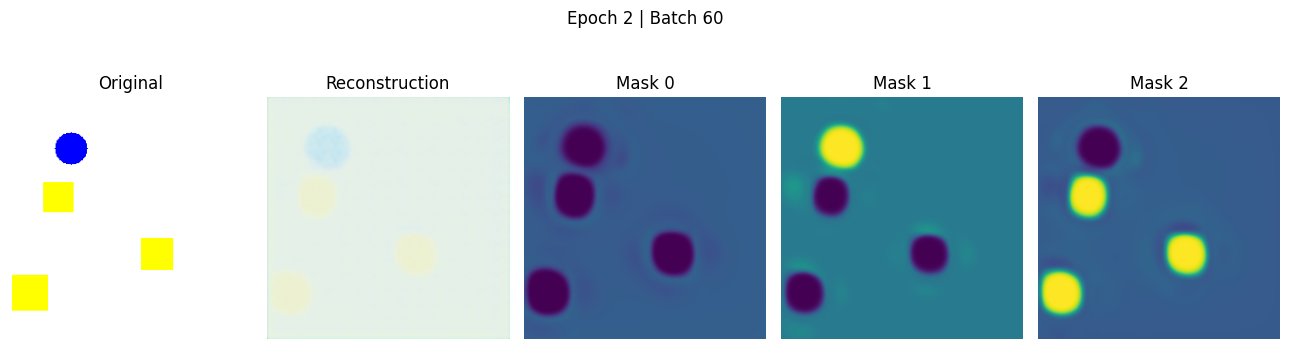

Epoch 2/10: 100%|██████████| 63/63 [00:19<00:00,  3.21it/s, entropy_loss=9.48e-5, recon_loss=1.3, tv_loss=6.48e-6] 


Epoch 2 complete. Recon Loss: 1.2954


Epoch 3/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=9.67e-5, recon_loss=1.24, tv_loss=6.03e-6]

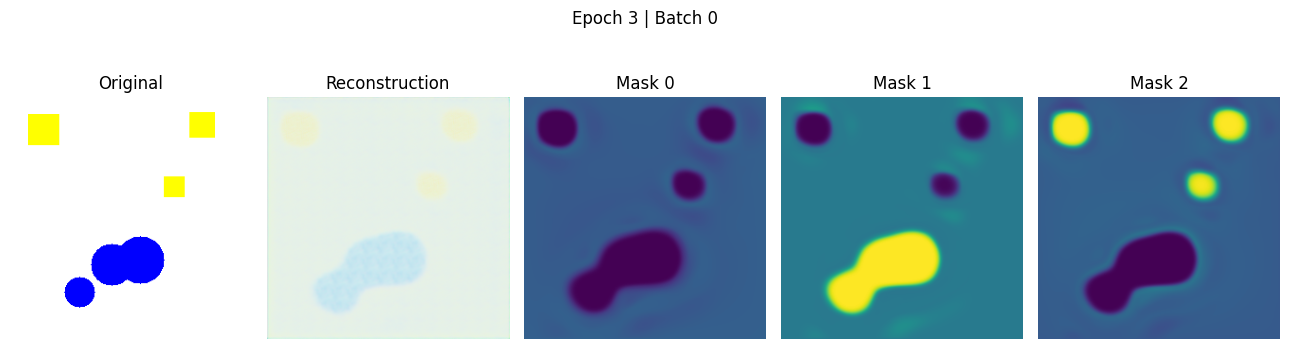

Epoch 3/10:  32%|███▏      | 20/63 [00:06<00:12,  3.37it/s, entropy_loss=0.000102, recon_loss=1.1, tv_loss=4.62e-6] 

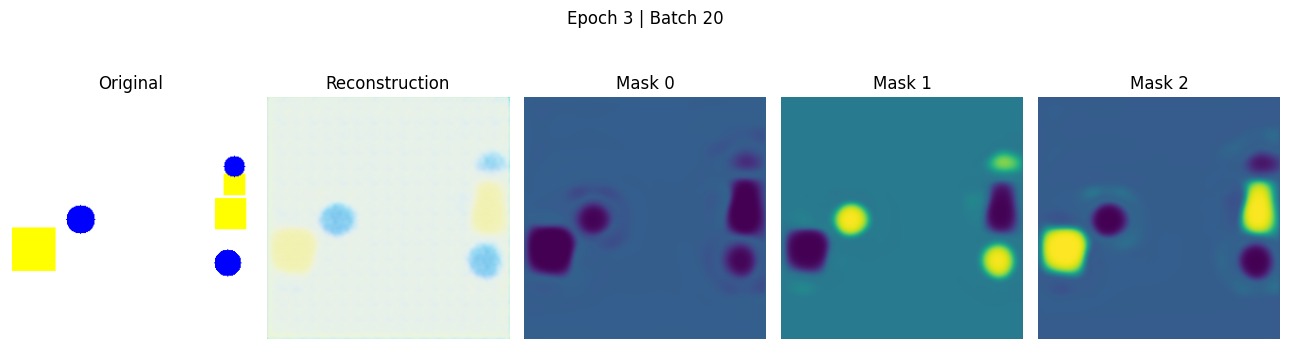

Epoch 3/10:  63%|██████▎   | 40/63 [00:12<00:06,  3.36it/s, entropy_loss=0.0001, recon_loss=1.06, tv_loss=5.23e-6]   

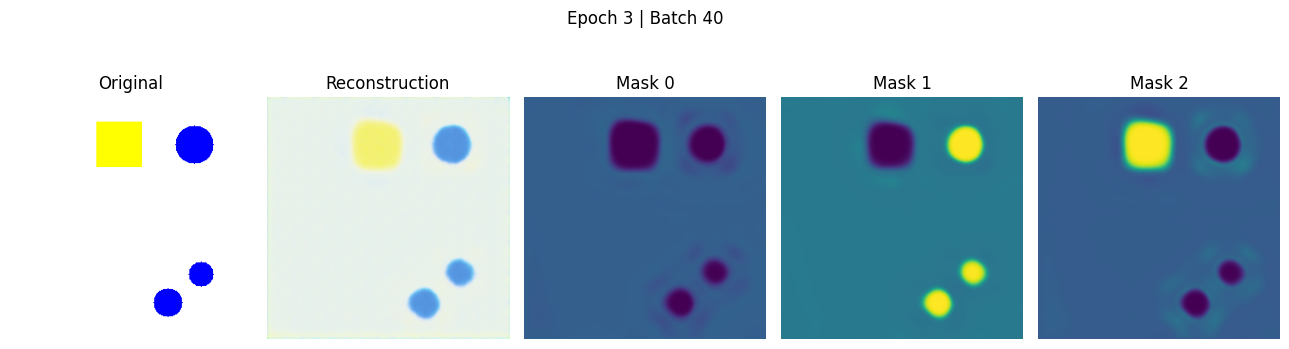

Epoch 3/10:  95%|█████████▌| 60/63 [00:18<00:00,  3.38it/s, entropy_loss=0.000102, recon_loss=0.934, tv_loss=4.63e-6]

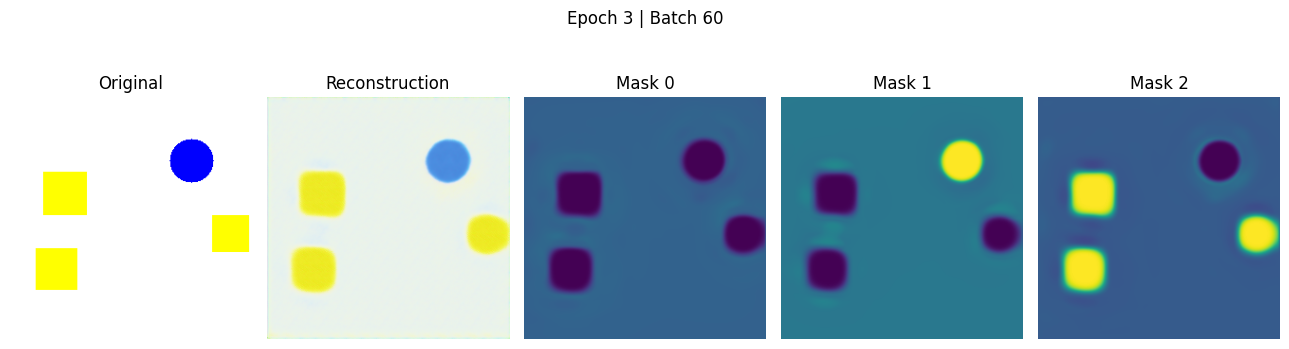

Epoch 3/10: 100%|██████████| 63/63 [00:19<00:00,  3.21it/s, entropy_loss=0.000103, recon_loss=0.929, tv_loss=4.59e-6]


Epoch 3 complete. Recon Loss: 0.9291


Epoch 4/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000102, recon_loss=0.983, tv_loss=4.91e-6]

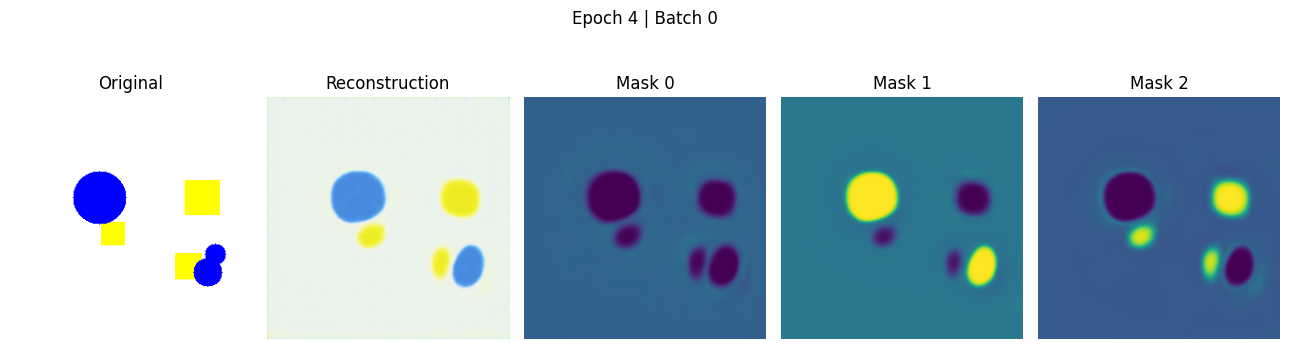

Epoch 4/10:  32%|███▏      | 20/63 [00:06<00:12,  3.38it/s, entropy_loss=0.000103, recon_loss=0.873, tv_loss=4.85e-6]

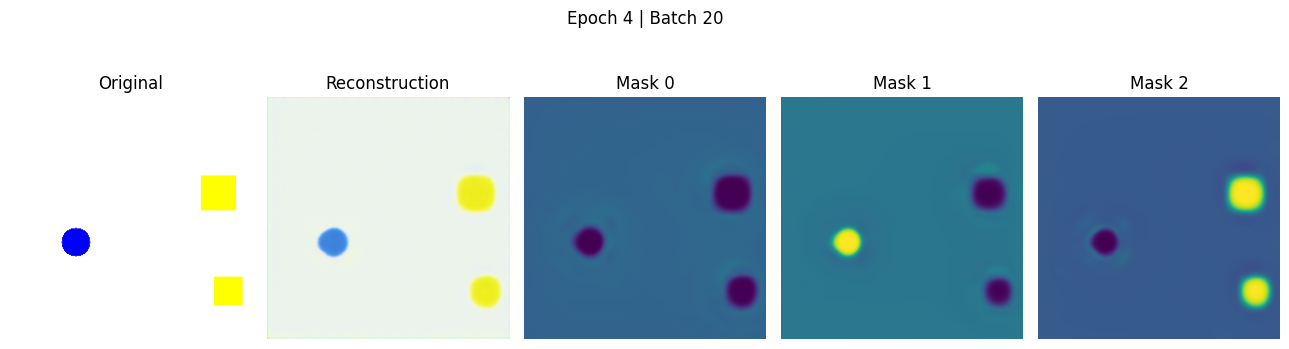

Epoch 4/10:  63%|██████▎   | 40/63 [00:12<00:06,  3.37it/s, entropy_loss=0.000102, recon_loss=0.815, tv_loss=5.11e-6]

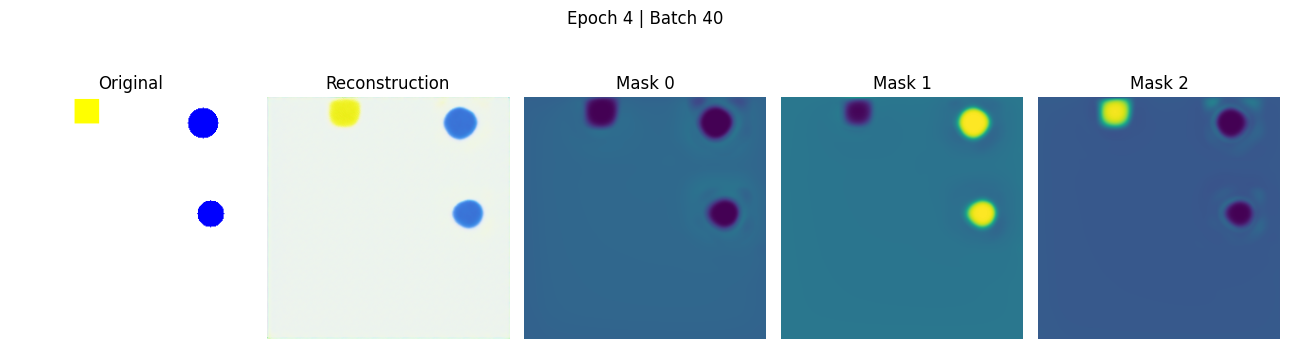

Epoch 4/10:  95%|█████████▌| 60/63 [00:19<00:00,  3.38it/s, entropy_loss=0.000101, recon_loss=0.836, tv_loss=6.11e-6]

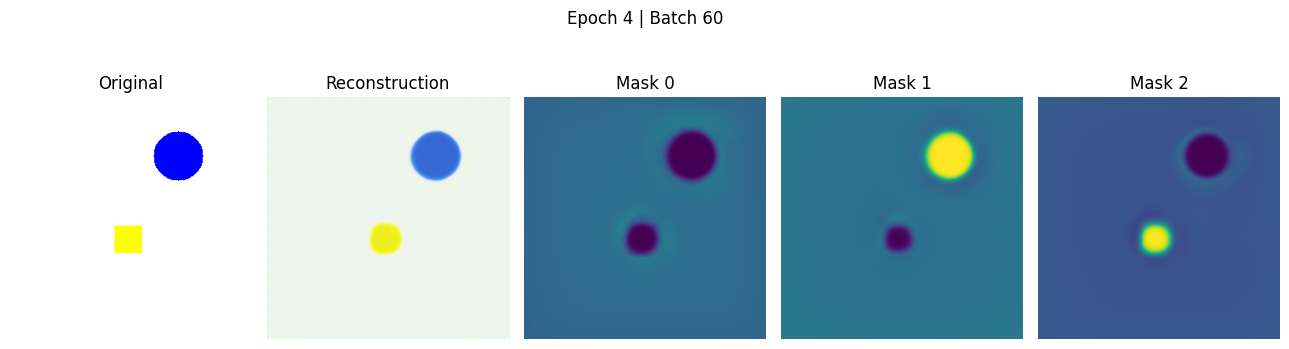

Epoch 4/10: 100%|██████████| 63/63 [00:19<00:00,  3.18it/s, entropy_loss=0.000103, recon_loss=0.752, tv_loss=4.86e-6]


Epoch 4 complete. Recon Loss: 0.7520


Epoch 5/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000102, recon_loss=0.787, tv_loss=5.28e-6]

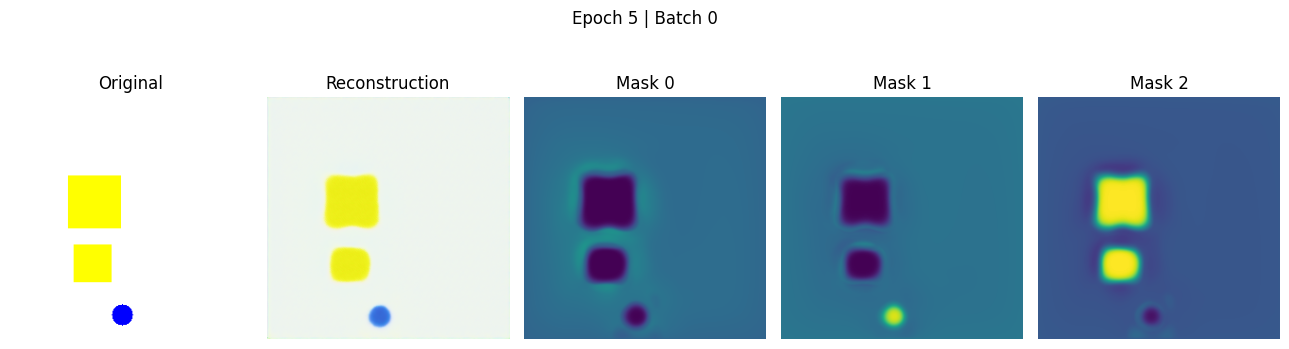

Epoch 5/10:  32%|███▏      | 20/63 [00:06<00:12,  3.40it/s, entropy_loss=0.000101, recon_loss=0.783, tv_loss=5.97e-6]

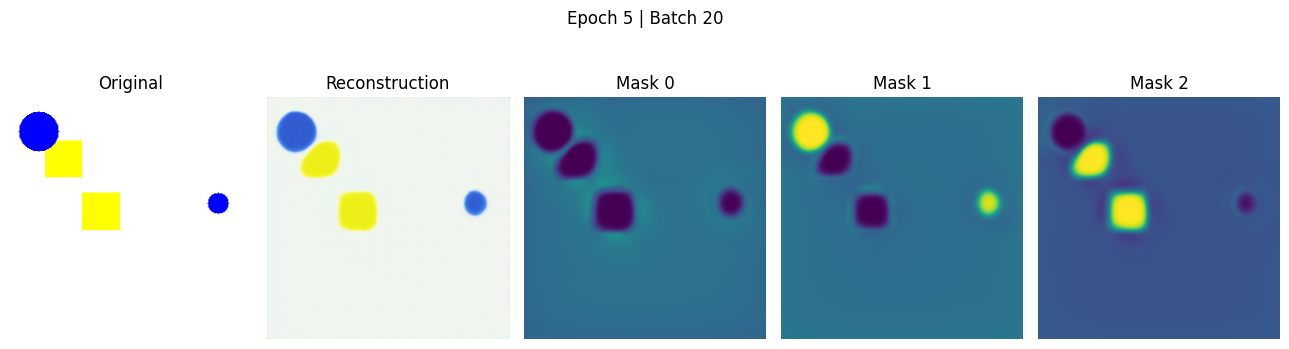

Epoch 5/10:  63%|██████▎   | 40/63 [00:12<00:06,  3.42it/s, entropy_loss=0.000103, recon_loss=0.681, tv_loss=5.34e-6]

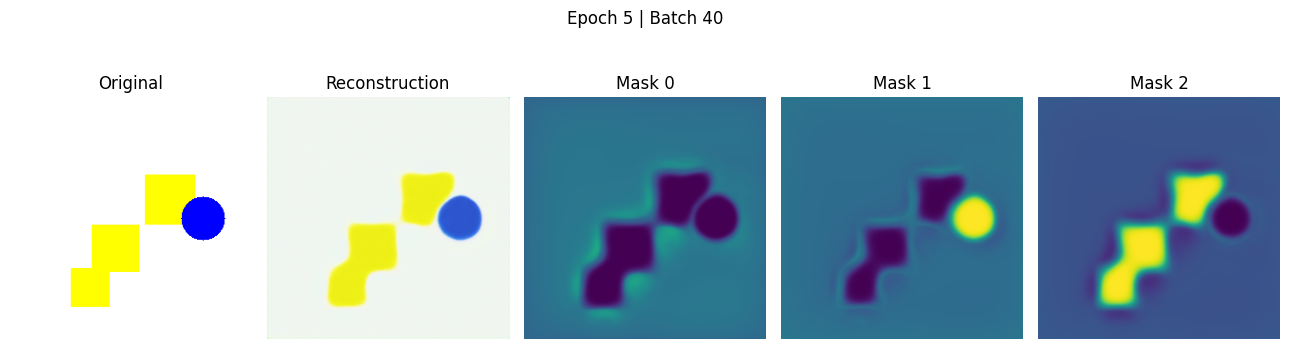

Epoch 5/10:  95%|█████████▌| 60/63 [00:18<00:00,  3.40it/s, entropy_loss=0.000102, recon_loss=0.686, tv_loss=5.9e-6] 

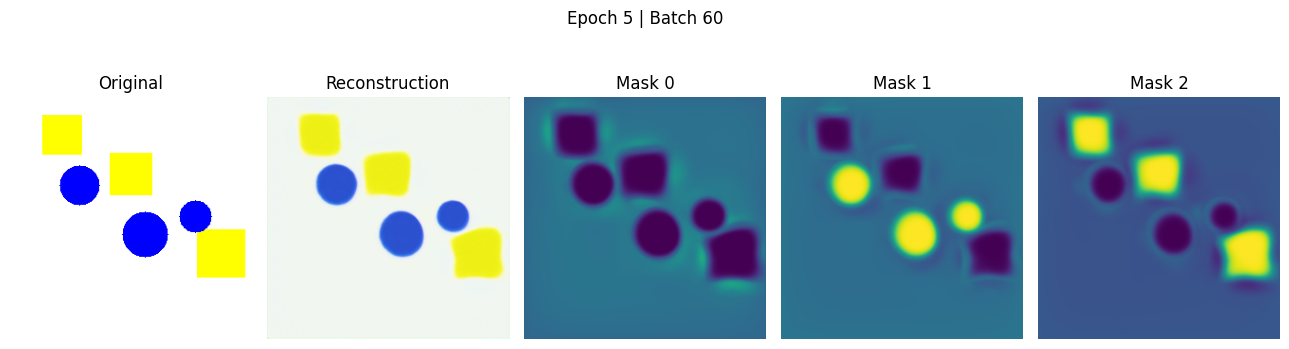

Epoch 5/10: 100%|██████████| 63/63 [00:19<00:00,  3.26it/s, entropy_loss=0.000103, recon_loss=0.634, tv_loss=5.42e-6]


Epoch 5 complete. Recon Loss: 0.6341


Epoch 6/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000102, recon_loss=0.706, tv_loss=6.08e-6]

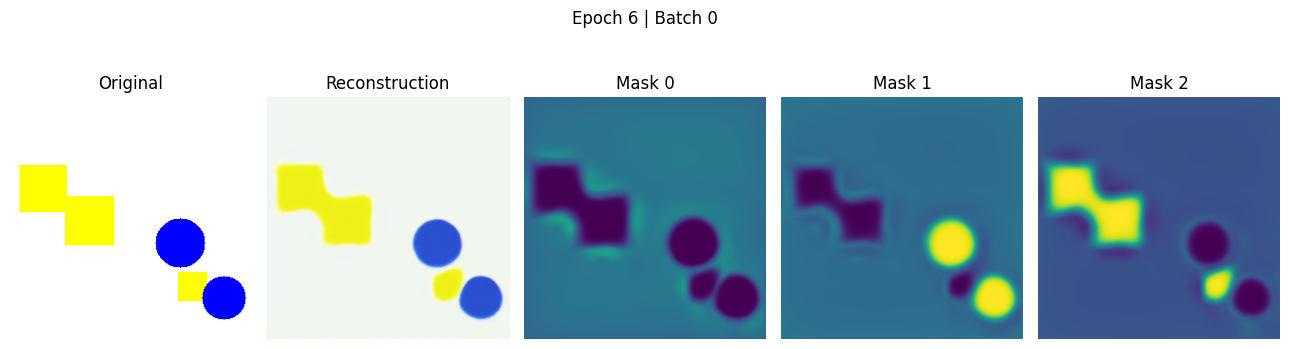

Epoch 6/10:  32%|███▏      | 20/63 [00:06<00:12,  3.40it/s, entropy_loss=0.000101, recon_loss=0.676, tv_loss=6.35e-6]

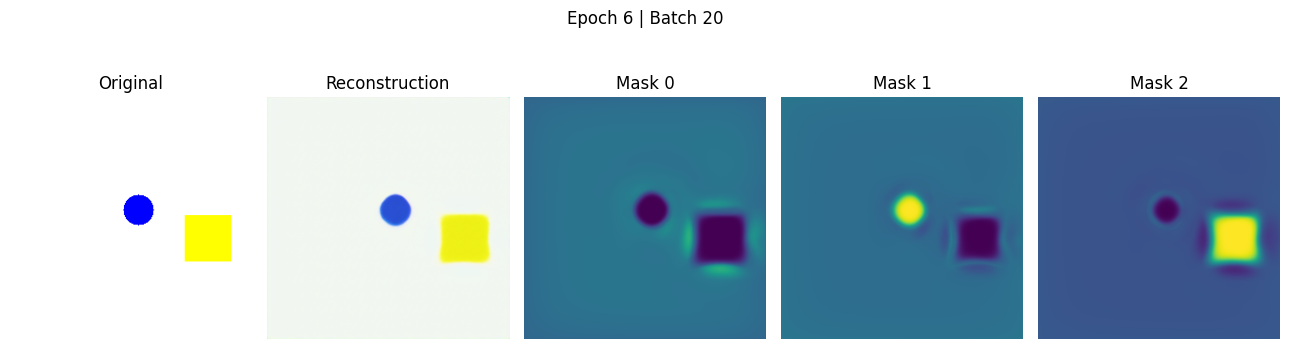

Epoch 6/10:  63%|██████▎   | 40/63 [00:12<00:06,  3.39it/s, entropy_loss=0.000102, recon_loss=0.598, tv_loss=6.2e-6] 

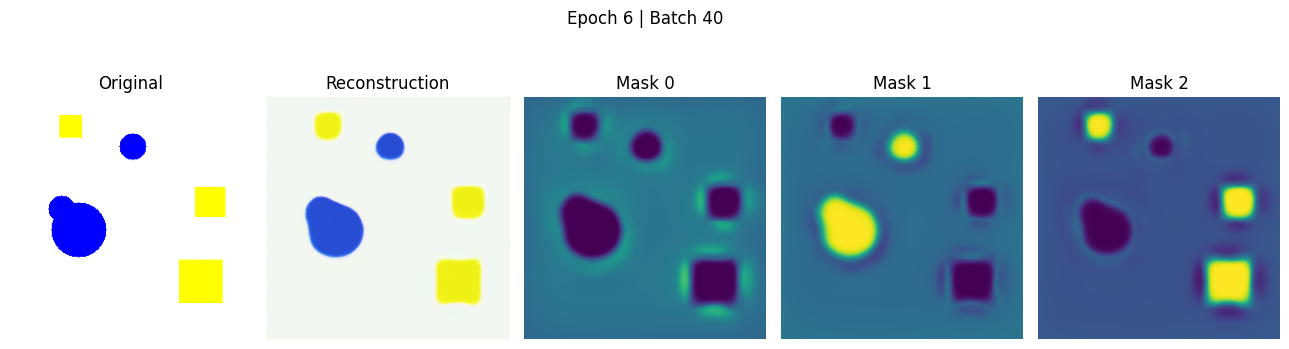

Epoch 6/10:  95%|█████████▌| 60/63 [00:18<00:00,  3.40it/s, entropy_loss=0.000101, recon_loss=0.624, tv_loss=6.68e-6]

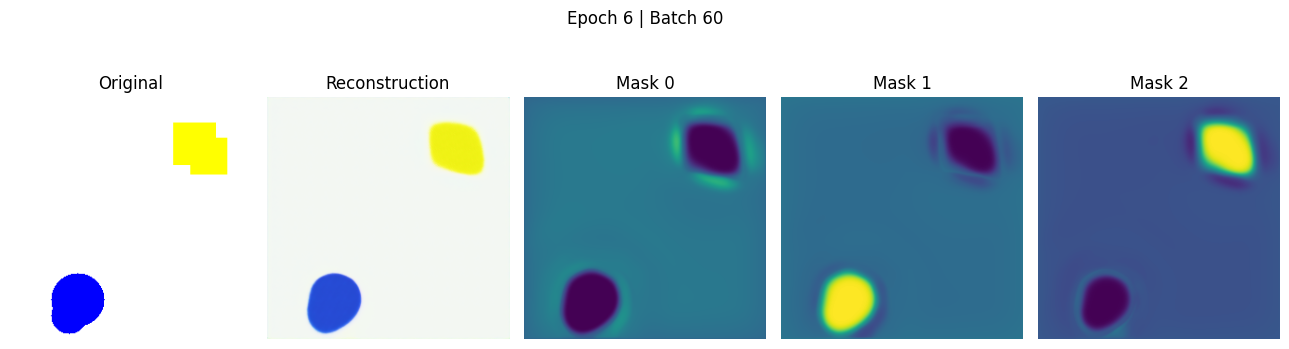

Epoch 6/10: 100%|██████████| 63/63 [00:19<00:00,  3.25it/s, entropy_loss=9.91e-5, recon_loss=0.636, tv_loss=7.72e-6] 


Epoch 6 complete. Recon Loss: 0.6358


Epoch 7/10:   0%|          | 0/63 [00:00<?, ?it/s, entropy_loss=0.000103, recon_loss=0.565, tv_loss=5.6e-6]

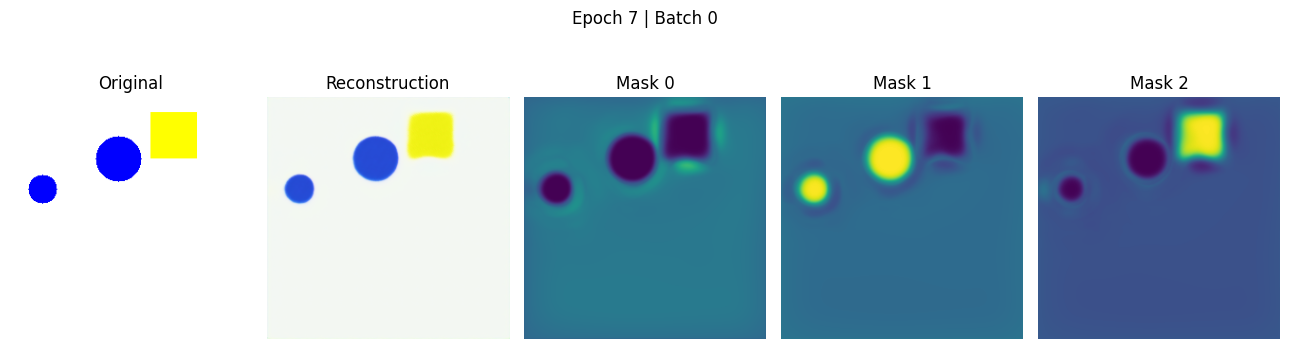

Epoch 7/10:  19%|█▉        | 12/63 [00:04<00:17,  2.94it/s, entropy_loss=0.000102, recon_loss=0.558, tv_loss=6.04e-6]


KeyboardInterrupt: 

In [4]:
# Training Loop
for epoch in range(epochs):
    loop = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}')
    for batch_idx, (data, _) in enumerate(loop):
        
        # Forward pass setup
        seg_optimizer.zero_grad()
        rec_optimizer.zero_grad()
        
        full_img = data[-1].to(device)
        
        seg_logits = seg_model(full_img)
        seg_probs = F.softmax(seg_logits, dim=1)
        reconstructions = rec_model(full_img, seg_probs)

        # Losses
        recon_loss = 0
        for target_img, pred_img in zip(data, reconstructions):
            target_img = target_img.to(device)
            recon_loss += recon_loss_fn(pred_img, target_img)
        
        tv_loss = tv_loss_fn(seg_probs)
        entropy_loss = entropy_loss_fn(seg_logits)
        
        # Total Loss & Backprop
        total_loss = recon_loss + entropy_loss + tv_loss
        total_loss.backward()
        
        seg_optimizer.step()
        rec_optimizer.step()
        
        loop.set_postfix(
            recon_loss=recon_loss.item(),
            entropy_loss=entropy_loss.item(),
            tv_loss=tv_loss.item(),
        )
        
        # Save visual progress every 20 batches
        if batch_idx % 20 == 0:
            # Pass seg_probs[0] to the visualization function
            visualize_results(full_img[0], reconstructions[-1][0], seg_probs[0], epoch, batch_idx)

    print(f"Epoch {epoch} complete. Recon Loss: {recon_loss.item():.4f}")